In [1]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
import numpy as np
from fairchem.core.datasets import AseDBDataset
import torch
from torch.nn import Linear
from torch_geometric.nn import SchNet
from torch_geometric.data import Data
from torch_cluster import radius_graph
import matplotlib.pyplot as plt
from read_multi_ase import *
from extract_test import *

W0504 07:20:35.067000 47267 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
class EmbeddedSchNet(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 128,
                 num_filters: int = 128,
                 num_interactions: int = 6,
                 num_gaussians: int = 50,
                 cutoff: int = 12,
                 max_num_neighbors: int = 32,
                 readout: str = "mean",
                 dipole: bool = False,
                 mean: float = None,
                 std: float = None,
                 atomref: torch.Tensor = None,
                 extra_feat_dim: int = 1,
                 train_mean: float = None,
                 train_std: float = None):
        super().__init__()

        # print(extra_feat_dim)
        # print(num_interactions)

        #Create SchNet module with parameters
        self.schnet = SchNet(
            hidden_channels = hidden_channels,
            num_filters = num_filters,
            num_interactions = num_interactions,
            num_gaussians = num_gaussians,
            cutoff = cutoff,
            max_num_neighbors = max_num_neighbors,
            readout = readout,
            dipole = dipole,
            mean = mean,
            std = std,
            atomref = atomref)

        #Extra Linear layer to handle extra embedded features
        self.linear = Linear(extra_feat_dim, hidden_channels)

        #Keep track of training mean and std for normalization function
        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        #Extract each value from data
        atomic_num, positions, batch, extra_feat = data.z, data.pos, data.batch, data.extra_feat

        #Initialize atom embeddings through SchNet
        atom_embeddings = self.schnet.embedding(atomic_num)
        # print(extra_feat.shape)

        #Project extra features on linear layer
        extra_linear = self.linear(extra_feat)

        #Combine extra features and initialized atom embeddings
        atom_embeddings = atom_embeddings + extra_linear

        #Use SchNet utilities to extract edge indexes and edge weighs based on position and batch
        edge_index, edge_weight = self.schnet.interaction_graph(positions, batch)
        #Use SchNet utilities to obtain edge attribute based on edge weights
        edge_attr = self.schnet.distance_expansion(edge_weight)

        #Iterate through each interaction block manually to simulate Schnet
        for interaction_block in self.schnet.interactions:
            atom_embeddings = atom_embeddings + interaction_block(atom_embeddings, edge_index, edge_weight, edge_attr)

        atom_embeddings = self.schnet.lin1(atom_embeddings)
        atom_embeddings = self.schnet.act(atom_embeddings)
        atom_embeddings = self.schnet.lin2(atom_embeddings)

        #Ensure the readout is based on model's hyperparameter
        output = self.schnet.readout(atom_embeddings, batch)

        return output

#Determine the device to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Initialize model with desired parameters
bio_model = EmbeddedSchNet(hidden_channels=128, num_filters=128, extra_feat_dim = 2).to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss()


def train(model: EmbeddedSchNet, train_data: list):
    model.train()
    #Keep track of total loss for all data
    total_train_loss = 0

    for data in train_data:
        data = data.to(device)

        #Reset optimizers
        optimizer.zero_grad()

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)

        #Determine train loss based on loss function with predictions and targets
        train_loss = loss_function(y_pred, y_target)

        #Backward step to calculate gradients
        train_loss.backward()
        #Updated optimizers
        optimizer.step()

        #Add train loss of current data to total train loss
        total_train_loss += train_loss.item()

    return total_train_loss / len(train_data)

@torch.no_grad()
def evaluate(model: EmbeddedSchNet, val_data: list):
    model.eval()
    total_val_loss = 0

    for data in val_data:
        data = data.to(device)

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)

        #Determine validation loss based on loss function with predictions and targets
        val_loss = loss_function(y_pred, y_target)

        #Add validation loss of current data to total validation loss
        total_val_loss += val_loss.item()

    return total_val_loss / len(val_data)

@torch.no_grad()
def test(model: EmbeddedSchNet, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    n_molecules = 0

    for data in test_data:
        data = data.to(device)

        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)


        y_pred = y_pred * model.std + model.mean
        y_target = y_target * model.std + model.mean


        mae = torch.abs(y_pred - y_target).sum()
        mse = ((y_pred - y_target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        n_molecules += y_target.size(0)

    mean_mae = total_mae / n_molecules
    rmse = (total_mse / n_molecules) ** 0.5

    return mean_mae, rmse


def plot_losses(train_loss, val_loss):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss',
             linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SchNet Model Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [41]:
dataset_path = "./train_4M/data0000.aselmdb"
dataset = AseDBDataset({"src": dataset_path})

In [42]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
# bio_scaler = feature_scaler(bio_sample, ["mulliken_charges"])


In [4]:
bio_sample[0][0].info["mulliken_charges"]

array([-0.695314,  0.30106 , -0.317835, -0.877275, -0.798128,  0.11042 ,
        0.227712,  0.379934,  0.171224,  0.208601,  0.2896  ])

In [5]:
bio_sample[0][0].info["lowdin_charges"]

array([-0.131184,  0.05709 , -0.630557, -0.377947, -0.165803,  0.027029,
        0.073843, -0.012825,  0.059323,  0.074559,  0.026472])

In [43]:
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val = split_data(bio_data, 0.8)

Processed 1000 atoms


In [44]:
bio_train[0].extra_feat

tensor([[-0.0617],
        [-0.3986],
        [ 0.0062],
        [ 0.0400],
        [ 0.1063],
        [ 0.1338],
        [ 0.1034],
        [ 0.0014],
        [ 0.0658],
        [ 0.0083],
        [-0.3243],
        [ 0.0305],
        [ 0.0676],
        [ 0.1025],
        [ 0.1116],
        [ 0.0071]])

In [45]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)

In [46]:
bio_val = scale_features(bio_val, train_scaler)

In [10]:
bio_train[0].extra_feat

tensor([[-0.1198, -0.9398],
        [-1.1089,  0.4228],
        [-0.5424,  0.7158],
        [ 0.7183,  0.6526],
        [ 0.4667,  0.4715],
        [ 0.3878,  0.4713],
        [ 0.6475,  0.8272],
        [ 0.6429,  0.9513],
        [ 0.4993,  0.4178],
        [-0.5960,  0.6880],
        [ 0.0517, -1.5346],
        [-0.9586,  0.3120],
        [ 0.4227,  0.6343],
        [ 0.3279,  0.5012],
        [ 0.5975,  0.7940],
        [ 0.2763,  0.4426]])

In [47]:
bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)

In [48]:
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [49]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 6.9015 | Val Loss: 5.1289
Epoch 006 | Train Loss: 0.9291 | Val Loss: 1.2856
Epoch 011 | Train Loss: 0.5708 | Val Loss: 0.6908
Epoch 016 | Train Loss: 0.5404 | Val Loss: 0.5977
Epoch 021 | Train Loss: 0.5809 | Val Loss: 0.7099
Epoch 026 | Train Loss: 0.5398 | Val Loss: 0.5422
Epoch 031 | Train Loss: 0.4853 | Val Loss: 0.5352
Epoch 036 | Train Loss: 0.6297 | Val Loss: 0.5564
Epoch 041 | Train Loss: 0.5447 | Val Loss: 0.6051
Epoch 046 | Train Loss: 0.4518 | Val Loss: 0.5240


In [7]:
def plot_losses(train_loss, val_loss):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss',
             linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SchNet Model Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

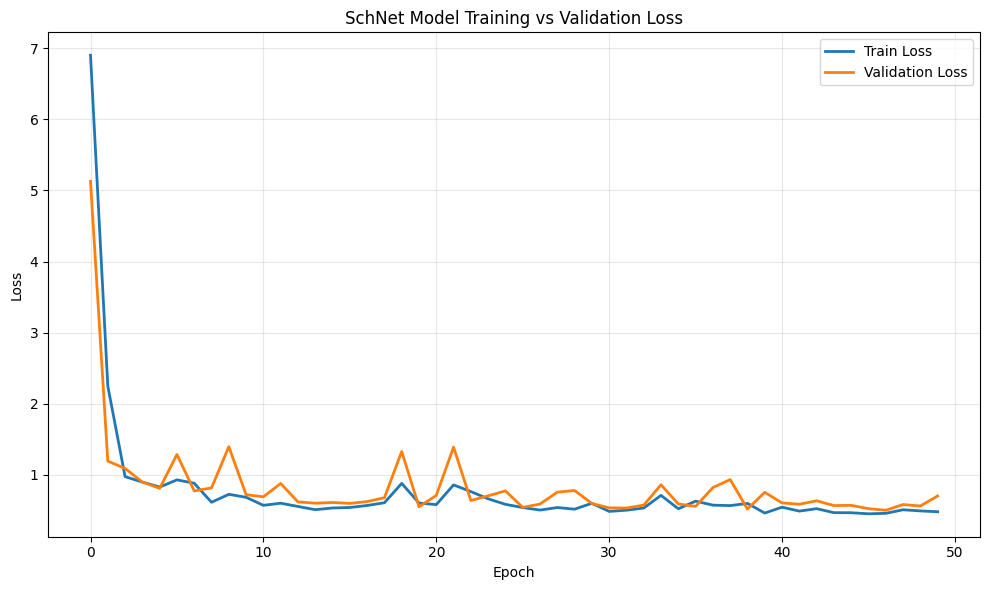

In [51]:
plot_losses(bio_train_losses, bio_val_losses)

In [52]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test = get_data(bio_testing, ["lowdin_charges"])
bio_test = scale_features(bio_test, train_scaler)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 200 atoms
Test MAE:  1.8119
Test RMSE: 2.1821


In [5]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample)
bio_train, bio_val = split_data(bio_data, 0.8)

[ 0  1  6  7  8  9 12 15 16 17 34 35 53 76]
Processed 1000 atoms


In [6]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [7]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 0.3958 | Val Loss: 0.4514
Epoch 006 | Train Loss: 0.3957 | Val Loss: 0.4460
Epoch 011 | Train Loss: 0.3897 | Val Loss: 0.4557
Epoch 016 | Train Loss: 0.3934 | Val Loss: 0.4428
Epoch 021 | Train Loss: 0.3898 | Val Loss: 0.4476
Epoch 026 | Train Loss: 0.3919 | Val Loss: 0.4537
Epoch 031 | Train Loss: 0.3903 | Val Loss: 0.4564
Epoch 036 | Train Loss: 0.3912 | Val Loss: 0.4470
Epoch 041 | Train Loss: 0.3902 | Val Loss: 0.4478
Epoch 046 | Train Loss: 0.3935 | Val Loss: 0.4449


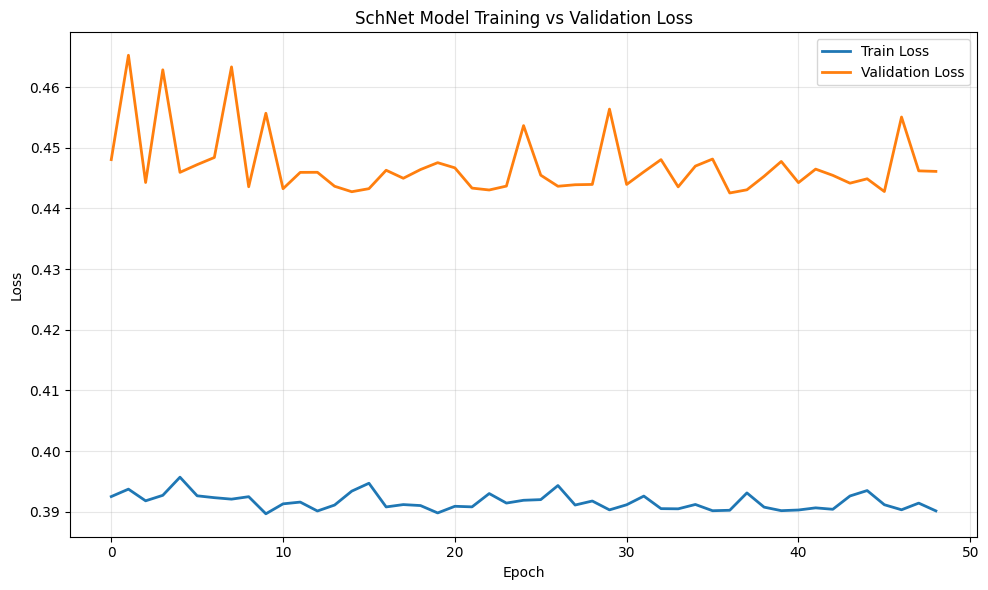

In [10]:
plot_losses(bio_train_losses[1:], bio_val_losses[1:])

In [26]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test = get_data(bio_testing, ["lowdin_charges"])
bio_test = scale_features(bio_test, train_scaler)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

[ 0  1  6  7  8  9 12 15 16 17 34]
Processed 200 atoms
Test MAE:  1.8243
Test RMSE: 2.2061


In [34]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val = split_data(bio_data, 0.8)

[ 0  1  6  7  8  9 12 15 16 17 34 35 53 76]
Processed 1000 atoms


In [35]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [30]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 26.9998 | Val Loss: 11.8318
Epoch 006 | Train Loss: 1.8713 | Val Loss: 1.8339
Epoch 011 | Train Loss: 1.5748 | Val Loss: 1.8085
Epoch 016 | Train Loss: 1.4207 | Val Loss: 1.3967
Epoch 021 | Train Loss: 0.9111 | Val Loss: 1.0694
Epoch 026 | Train Loss: 0.9128 | Val Loss: 0.8524
Epoch 031 | Train Loss: 0.7868 | Val Loss: 0.9456
Epoch 036 | Train Loss: 0.7427 | Val Loss: 0.6735
Epoch 041 | Train Loss: 0.7490 | Val Loss: 0.6349
Epoch 046 | Train Loss: 0.6854 | Val Loss: 0.7248


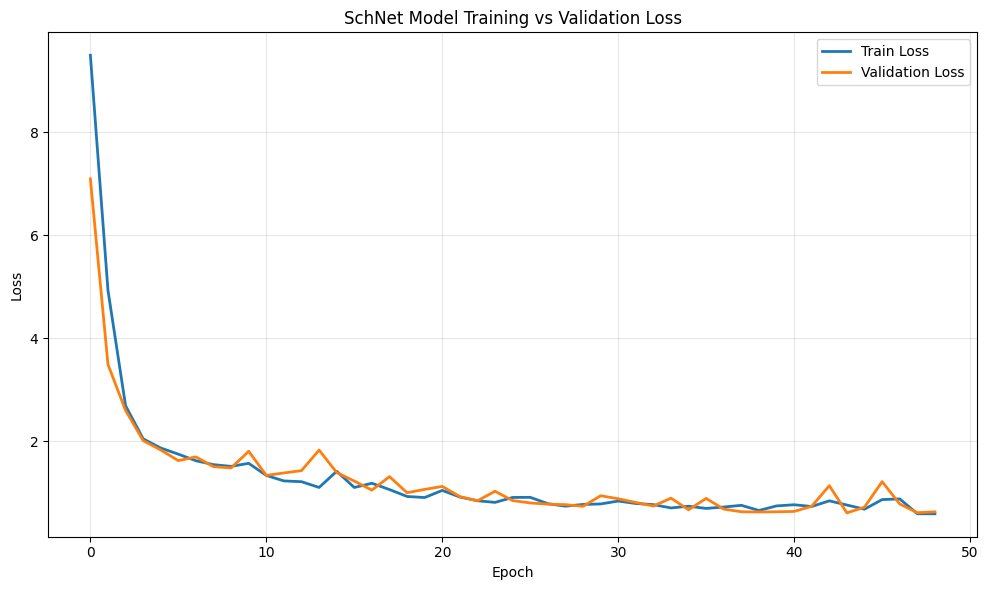

In [31]:
plot_losses(bio_train_losses[1:], bio_val_losses[1:])

In [32]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test = get_data(bio_testing, ["lowdin_charges", "mulliken_charges"])
bio_test = scale_features(bio_test, train_scaler)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

[ 0  1  6  7  8  9 12 15 16 17 34]
Processed 200 atoms
Test MAE:  2.6042
Test RMSE: 3.8516


## Updated version after broadcasting fix, lr =1e-4, cutoff = 10 with only lowdin charges

In [25]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [26]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [5]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3806 | Val Loss: 0.3924
Epoch 006 | Train Loss: 0.2940 | Val Loss: 0.3358
Epoch 011 | Train Loss: 0.2668 | Val Loss: 0.3137
Epoch 016 | Train Loss: 0.2595 | Val Loss: 0.3078
Epoch 021 | Train Loss: 0.2259 | Val Loss: 0.3040
Epoch 026 | Train Loss: 0.2083 | Val Loss: 0.3125
Epoch 031 | Train Loss: 0.1968 | Val Loss: 0.3007
Epoch 036 | Train Loss: 0.1839 | Val Loss: 0.2890
Epoch 041 | Train Loss: 0.1804 | Val Loss: 0.2921
Epoch 046 | Train Loss: 0.1551 | Val Loss: 0.3035


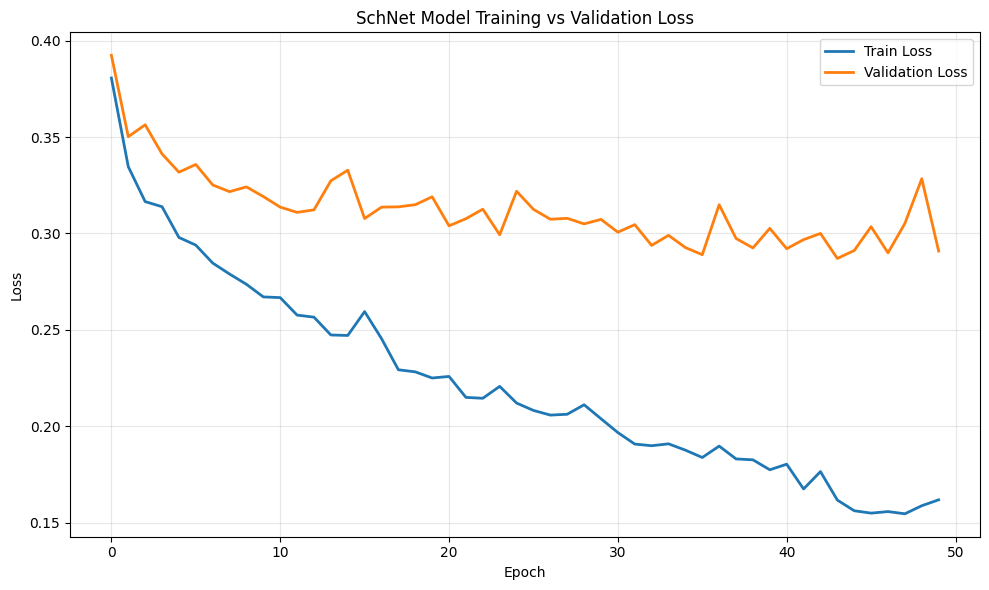

In [7]:
plot_losses(bio_train_losses, bio_val_losses)

In [8]:
bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.9491
Test RMSE: 1.3545


## Schnet same hyperparameters as above but with electronegativity feature

In [27]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [28]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [29]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3571 | Val Loss: 0.3659
Epoch 006 | Train Loss: 0.2999 | Val Loss: 0.3596
Epoch 011 | Train Loss: 0.2820 | Val Loss: 0.3451
Epoch 016 | Train Loss: 0.2737 | Val Loss: 0.3368
Epoch 021 | Train Loss: 0.2537 | Val Loss: 0.3321
Epoch 026 | Train Loss: 0.2447 | Val Loss: 0.3259
Epoch 031 | Train Loss: 0.2362 | Val Loss: 0.3193
Epoch 036 | Train Loss: 0.2264 | Val Loss: 0.3155
Epoch 041 | Train Loss: 0.2145 | Val Loss: 0.3180
Epoch 046 | Train Loss: 0.2118 | Val Loss: 0.3118


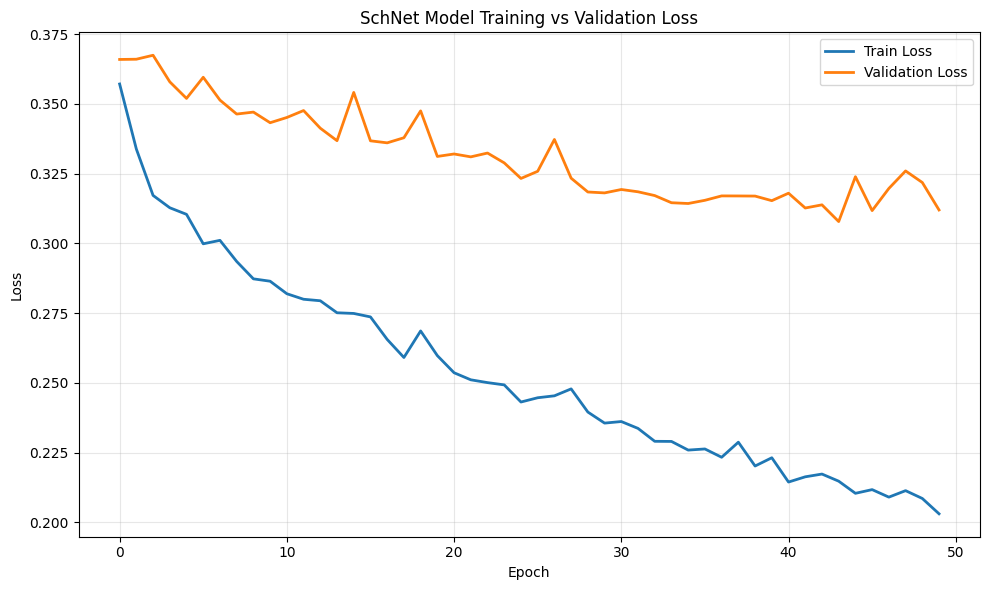

In [30]:
plot_losses(bio_train_losses, bio_val_losses)

In [31]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0841
Test RMSE: 1.5645


## Change interaction layers

In [ ]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 8, num_interactions = 4, extra_feat_dim = 2).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)

In [41]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 2000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 2000 atoms


In [42]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)
print(bio_train[0].extra_feat)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

tensor([[-1.1762,  0.1234],
        [-1.2548,  0.1234],
        [-1.0725,  0.1234],
        [ 0.2068,  1.3350],
        [-1.7032,  0.1234],
        [-0.0669,  1.3350],
        [ 0.5859, -0.7420],
        [ 0.5662, -0.7420],
        [ 0.6035, -0.7420],
        [ 0.5859, -0.7420],
        [ 0.5770, -0.7420],
        [ 0.5308, -0.7420],
        [-0.1423, -0.7420],
        [ 0.1603, -0.7420],
        [ 0.5152, -0.7420],
        [ 0.5872, -0.7420],
        [ 0.3683, -0.7420],
        [ 0.2928, -0.7420]])


In [43]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3876 | Val Loss: 0.3106
Epoch 006 | Train Loss: 0.3031 | Val Loss: 0.2847
Epoch 011 | Train Loss: 0.2897 | Val Loss: 0.2763
Epoch 016 | Train Loss: 0.2834 | Val Loss: 0.2710
Epoch 021 | Train Loss: 0.2630 | Val Loss: 0.2610
Epoch 026 | Train Loss: 0.2421 | Val Loss: 0.2497
Epoch 031 | Train Loss: 0.2310 | Val Loss: 0.2479
Epoch 036 | Train Loss: 0.2297 | Val Loss: 0.2431
Epoch 041 | Train Loss: 0.2207 | Val Loss: 0.2465
Epoch 046 | Train Loss: 0.2192 | Val Loss: 0.2414


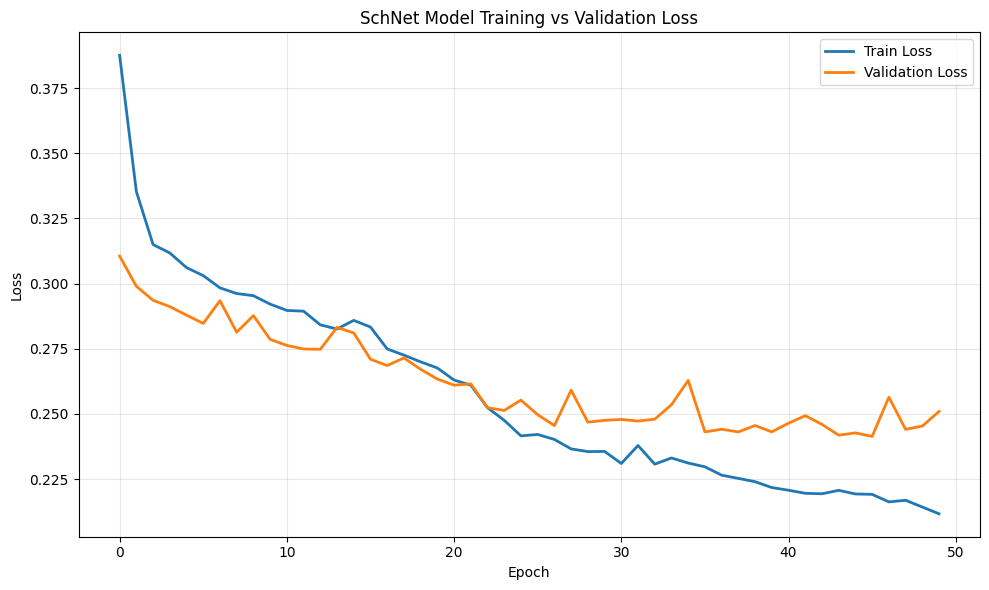

In [44]:
plot_losses(bio_train_losses, bio_val_losses)

In [45]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0981
Test RMSE: 1.5542


## Model with both lowdin and mulliken 

In [50]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 8, num_interactions = 4, extra_feat_dim = 3).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)

In [51]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges", "mulliken_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [52]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)
print(bio_train[0].extra_feat)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

tensor([[ 0.0881, -0.9078,  2.2789],
        [-1.4691,  0.3152,  0.1080],
        [-0.1550, -1.3626,  0.1080],
        [ 0.7694,  0.6684, -0.7457],
        [ 0.4529,  0.3548, -0.7457],
        [ 0.5086,  0.5289, -0.7457],
        [ 0.6194,  0.4957, -0.7457],
        [ 0.9121, -0.6325,  1.3032],
        [-2.2648,  0.6539,  0.1080],
        [ 0.7782, -0.8343,  1.3032],
        [ 1.4331, -0.3975,  1.3032],
        [ 0.7442,  0.5476, -0.7457],
        [ 0.4906,  0.4104, -0.7457],
        [ 0.6965,  0.4961, -0.7457],
        [ 0.6374,  0.5018, -0.7457],
        [ 0.8030,  0.4495, -0.7457],
        [ 0.8344,  0.4355, -0.7457]])


In [53]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.4152 | Val Loss: 0.2772
Epoch 006 | Train Loss: 0.3226 | Val Loss: 0.2421
Epoch 011 | Train Loss: 0.3060 | Val Loss: 0.2274
Epoch 016 | Train Loss: 0.2956 | Val Loss: 0.2304
Epoch 021 | Train Loss: 0.2836 | Val Loss: 0.2159
Epoch 026 | Train Loss: 0.2771 | Val Loss: 0.2133
Epoch 031 | Train Loss: 0.2691 | Val Loss: 0.2118
Epoch 036 | Train Loss: 0.2627 | Val Loss: 0.2100
Epoch 041 | Train Loss: 0.2599 | Val Loss: 0.2052
Epoch 046 | Train Loss: 0.2524 | Val Loss: 0.2026


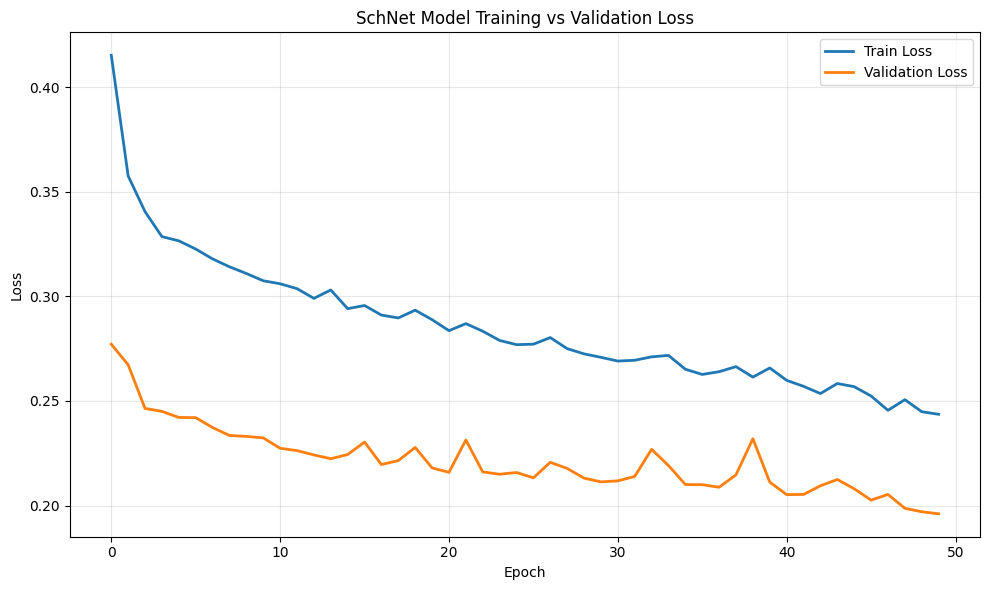

In [54]:
plot_losses(bio_train_losses, bio_val_losses)

In [55]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.1466
Test RMSE: 1.5738


## With just lowdin charges

Test MAE:  1.0203
Test RMSE: 1.5454

In [27]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 12, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)

In [28]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 5000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 5000 atoms


In [29]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)
print(bio_train[0].extra_feat)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

tensor([[-0.0089],
        [-2.8453],
        [ 0.0251],
        [ 0.4814],
        [ 0.5025],
        [ 0.4848],
        [ 0.4978],
        [-1.3398],
        [-2.5354],
        [ 0.1838],
        [-0.4342],
        [-0.4161],
        [-2.8224],
        [ 0.0966],
        [ 1.1640],
        [ 0.7077],
        [ 0.8818],
        [ 0.6969],
        [ 0.6720],
        [ 0.6424],
        [ 0.5842],
        [ 0.5800],
        [ 0.3447],
        [ 0.5572],
        [ 0.1616],
        [-0.3082],
        [ 0.4847],
        [ 0.4926],
        [ 0.5319],
        [ 0.0354],
        [-2.7119],
        [ 0.0802],
        [ 0.4538],
        [ 0.4961],
        [ 0.4687],
        [ 0.4492],
        [-0.9596],
        [-2.5176],
        [ 0.2199],
        [-0.5544],
        [-2.2459],
        [-0.4040],
        [-0.1486],
        [ 0.7782],
        [ 0.7120],
        [ 0.5739],
        [ 0.7250],
        [ 0.6183],
        [ 0.3114],
        [ 0.4654],
        [ 0.4954],
        [ 0.3679],
        [ 0.

In [30]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3450 | Val Loss: 0.3088
Epoch 006 | Train Loss: 0.2534 | Val Loss: 0.2411
Epoch 011 | Train Loss: 0.2295 | Val Loss: 0.2236
Epoch 016 | Train Loss: 0.2182 | Val Loss: 0.2161
Epoch 021 | Train Loss: 0.2039 | Val Loss: 0.2092
Epoch 026 | Train Loss: 0.1842 | Val Loss: 0.2001
Epoch 031 | Train Loss: 0.1733 | Val Loss: 0.1905
Epoch 036 | Train Loss: 0.1663 | Val Loss: 0.1825
Epoch 041 | Train Loss: 0.1587 | Val Loss: 0.1885
Epoch 046 | Train Loss: 0.1526 | Val Loss: 0.1772


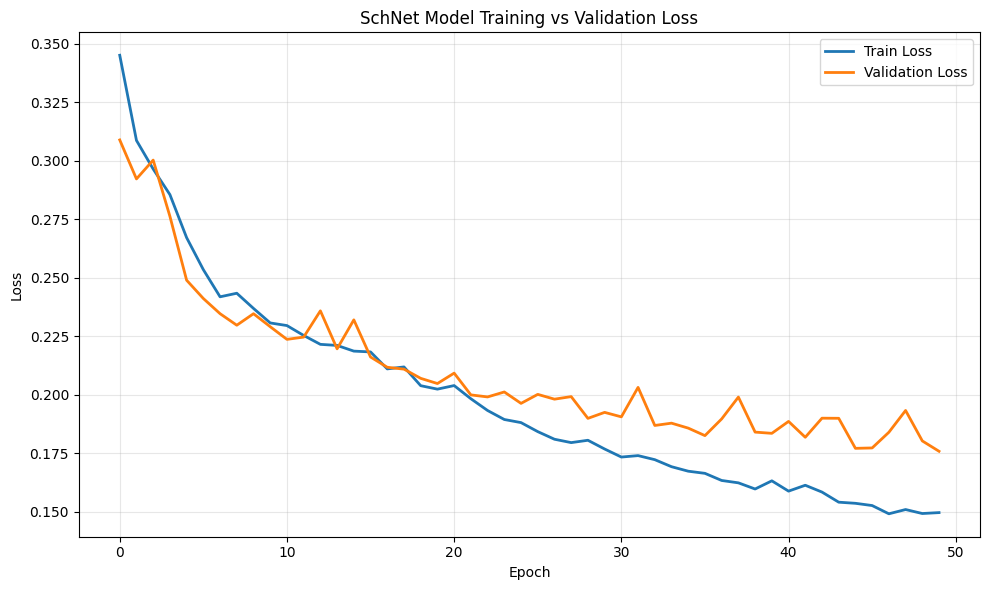

In [31]:
plot_losses(bio_train_losses, bio_val_losses)

In [32]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.8417
Test RMSE: 1.2412


## cutoff 12, en and lowdin, 5000 molecules lr 5e-5

In [3]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 12, num_interactions = 6, extra_feat_dim = 2).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)

In [4]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 5000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

[ 0  1  6  7  8  9 12 15 16 17 20 34 35 53 76]
Processed 5000 atoms


In [5]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)
# print(bio_train[0].extra_feat)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [6]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3438 | Val Loss: 0.3414
Epoch 006 | Train Loss: 0.2601 | Val Loss: 0.2775
Epoch 011 | Train Loss: 0.2307 | Val Loss: 0.2523
Epoch 016 | Train Loss: 0.2167 | Val Loss: 0.2480
Epoch 021 | Train Loss: 0.1976 | Val Loss: 0.2311
Epoch 026 | Train Loss: 0.1863 | Val Loss: 0.2352
Epoch 031 | Train Loss: 0.1775 | Val Loss: 0.2155
Epoch 036 | Train Loss: 0.1660 | Val Loss: 0.2079
Epoch 041 | Train Loss: 0.1589 | Val Loss: 0.2019
Epoch 046 | Train Loss: 0.1487 | Val Loss: 0.2080


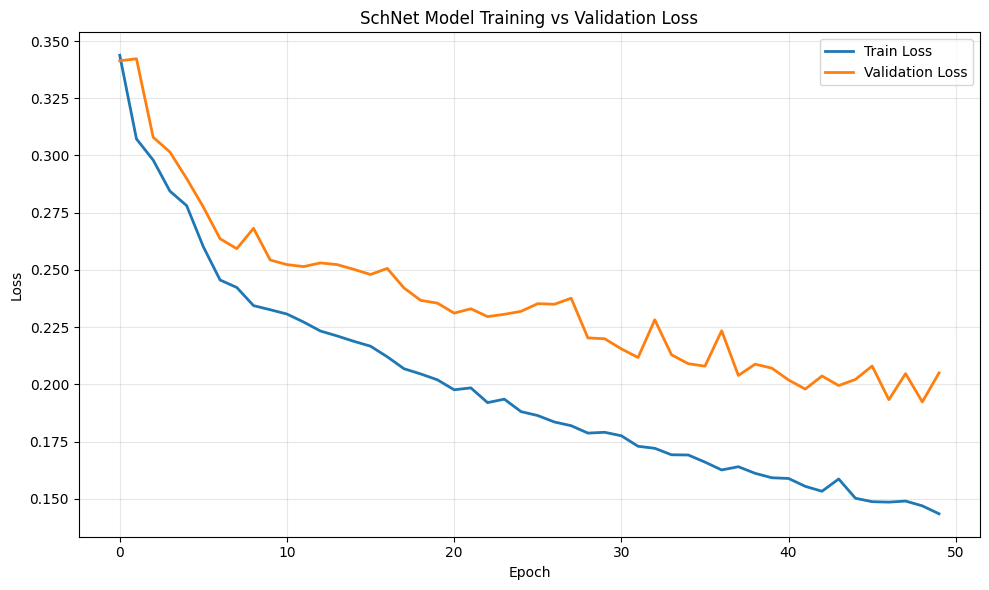

In [7]:
plot_losses(bio_train_losses, bio_val_losses)

In [8]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.8419
Test RMSE: 1.3202
